# Géocodage

`Geocoder` s'appuie sur **Nominatim** (OpenStreetMap) via `geopy`. Il
transforme un nom de lieu en coordonnées (et l'inverse) et renvoie un
`GeoDataFrame` en EPSG:4326.

> Nominatim est un service public : un `user_agent` explicite et un `delay`
> d'au moins 1 s entre les requêtes sont exigés par sa politique d'usage.
> `Geocoder` applique ce délai par défaut.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import cartograpy as cp
from cartograpy.data import Geocoder

geo = Geocoder(user_agent="cartograpy-demo")

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## Géocodage direct : adresse → coordonnées

`geocode` renvoie un couple `(GeoDataFrame, liste des requêtes non trouvées)`.

In [2]:
gdf, absents = geo.geocode("Abidjan, Côte d'Ivoire")
print("non trouvés :", absents)
gdf[["query", "address", "latitude", "longitude", "geometry"]]

Début du géocodage de 1 localité(s)...
Géocodage terminé.
non trouvés : []


,query,address,latitude,longitude,geometry
0,"Abidjan, Côte d'Ivoire","Abidjan, Côte d’Ivoire",5.320357,-4.016107,POINT (-4.01611 5.32036)


## Plusieurs lieux, contraints à un pays

`geocode_in_country` limite la recherche à un ou plusieurs codes pays
ISO alpha-2 — pratique pour éviter les homonymes.

In [3]:
villes = ["Abidjan", "Yamoussoukro", "Bouaké", "Korhogo", "San-Pédro"]
pts, absents = geo.geocode_in_country(villes, country_codes="ci")
print("non trouvés :", absents)
pts[["query", "latitude", "longitude"]]

non trouvés : []


,query,latitude,longitude
0,Abidjan,5.320357,-4.016107
1,Yamoussoukro,6.820007,-5.277603
2,Bouaké,7.689021,-5.028355
3,Korhogo,9.458070,-5.631629
4,San-Pédro,4.758999,-6.646392


📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.50
   Ratio données: 0.96
   Étendue: [-11.02, -0.11, 3.90, 11.17]


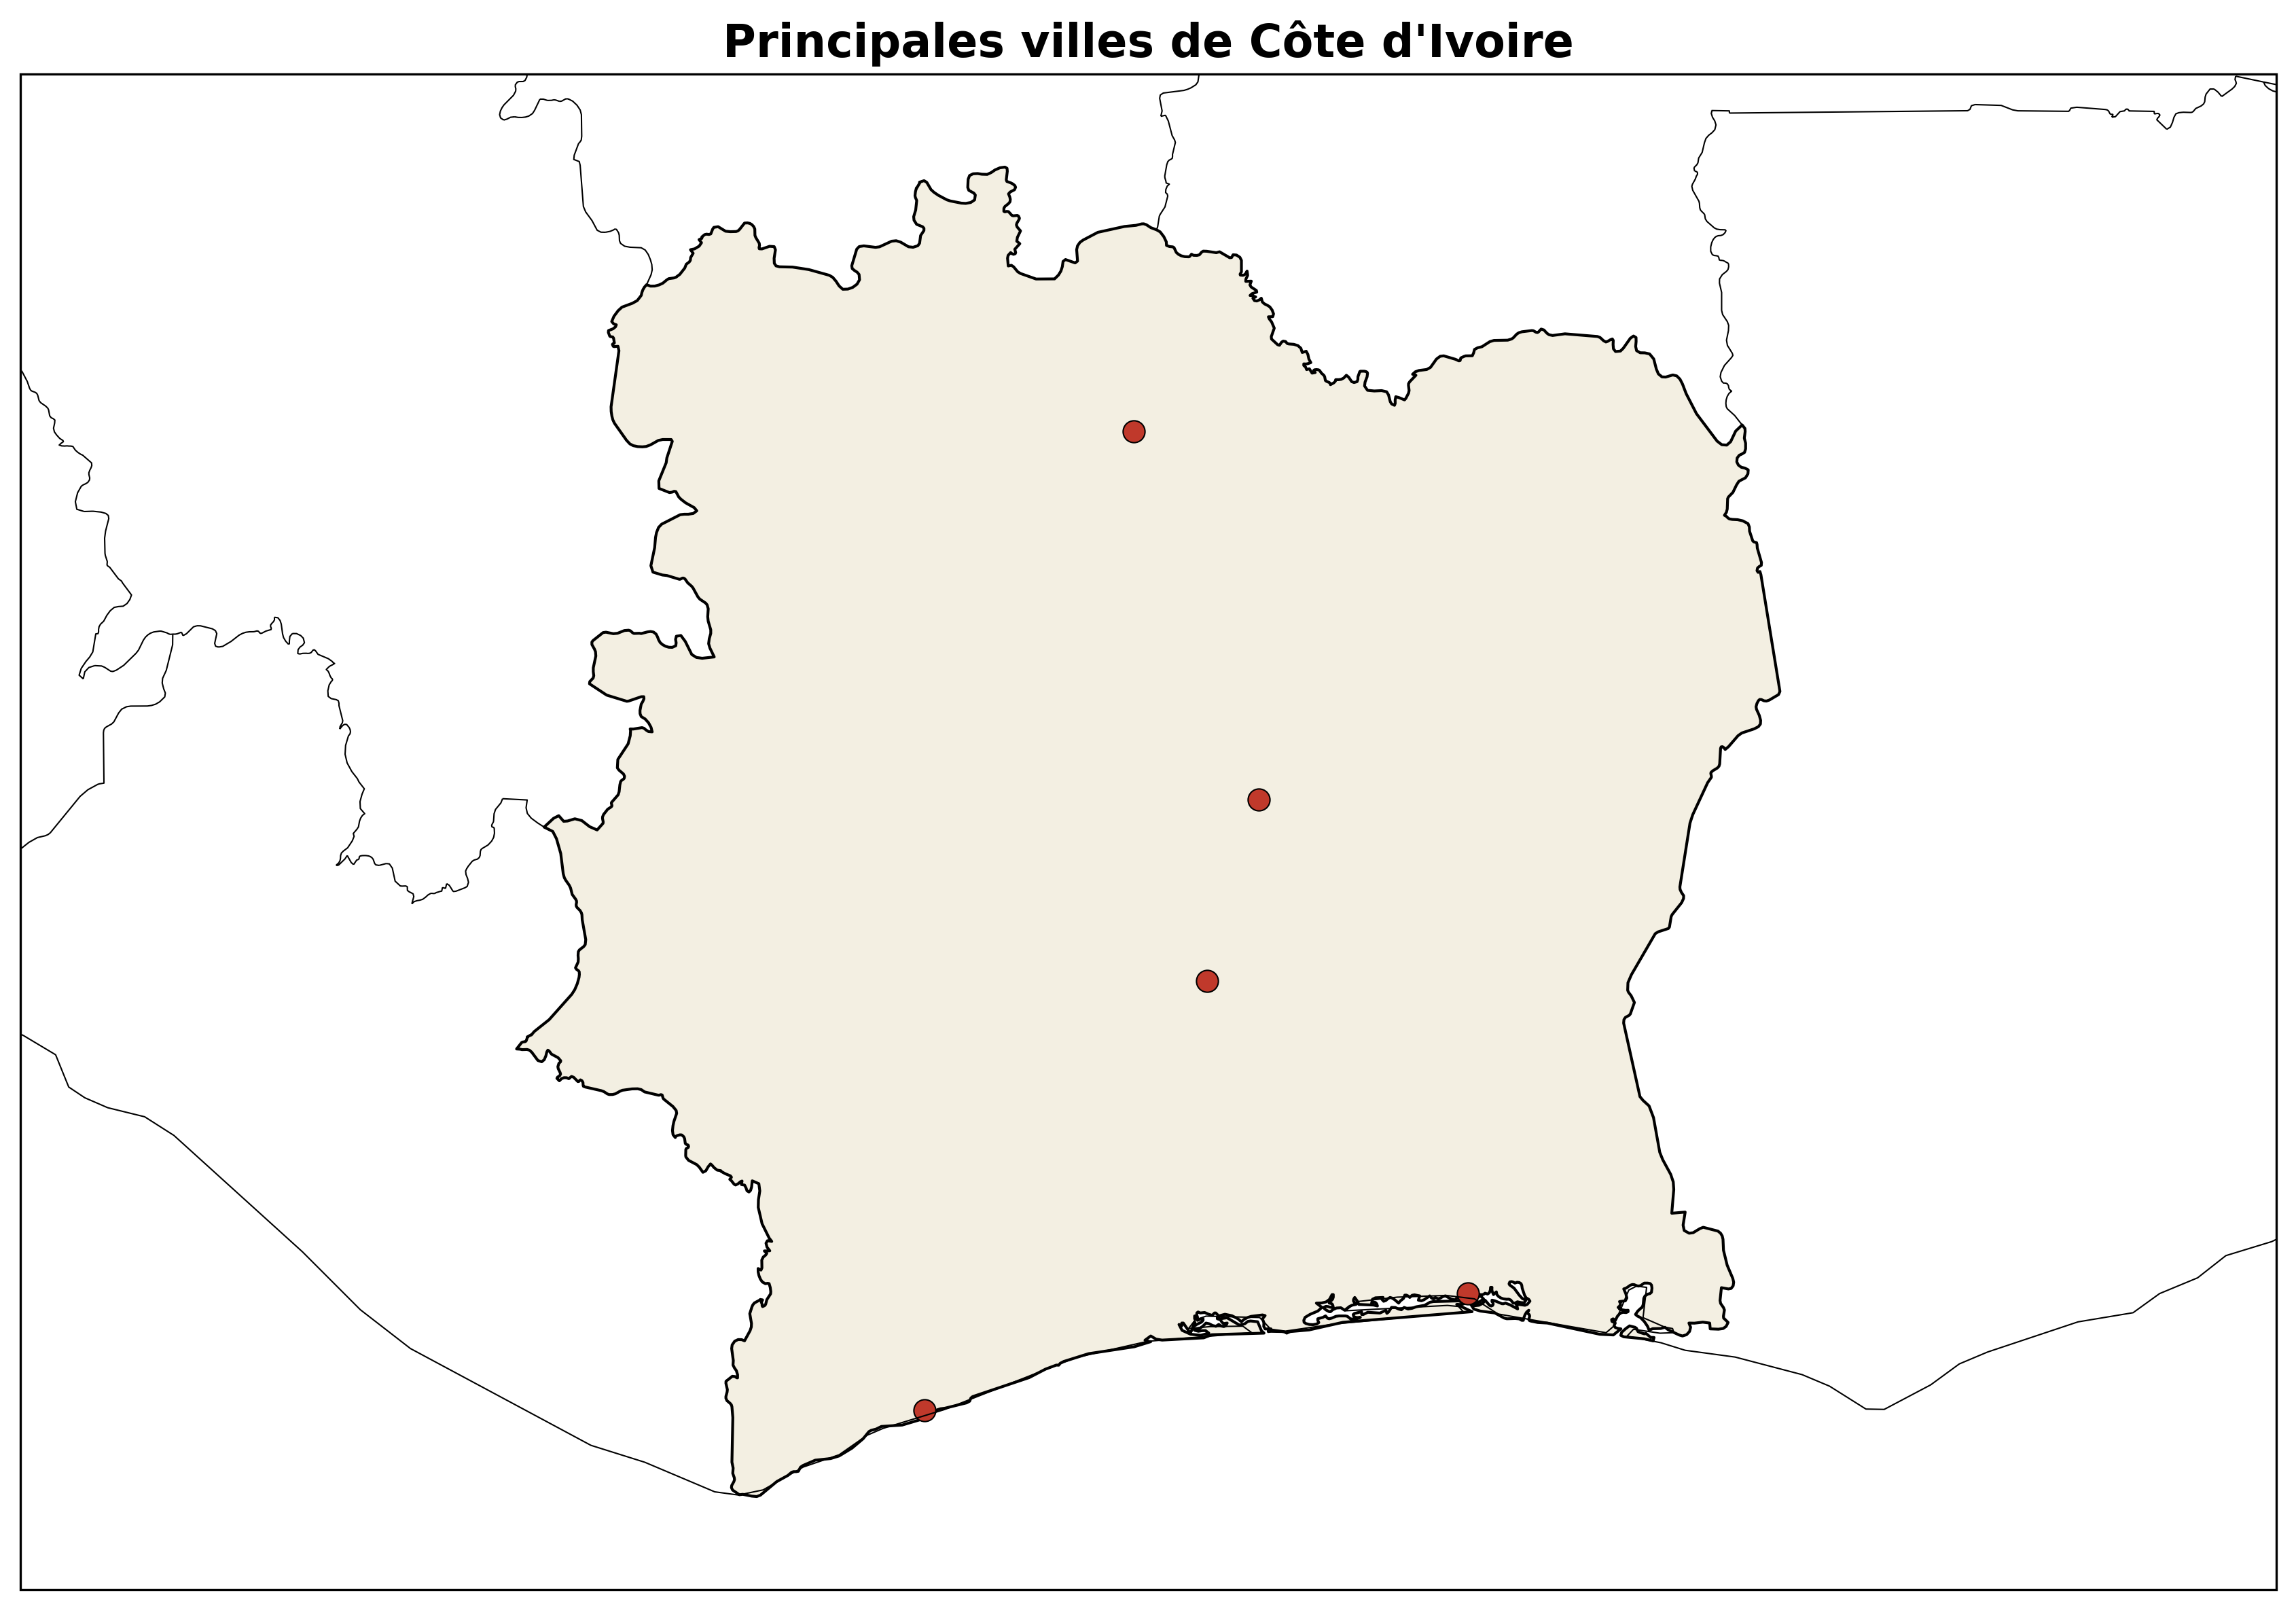

In [4]:
from cartograpy.data import Bound

civ = Bound().get_country("CIV").set_crs("EPSG:4326")

m = cp.Map(title="Principales villes de Côte d'Ivoire")
m.add_polygons(civ, facecolor="#f3efe2", edge_color="black", alpha=1)
m.add_points(pts, color="#c0392b", size=60)
m.show()

## Géocodage inverse : coordonnées → adresse

In [5]:
rev, absents = geo.reverse_geocode((6.827, -5.289))  # ~ centre de la Côte d'Ivoire
rev[["query", "address"]]

Début du géocodage inverse (coordonnées -> adresse) de 1 point(s)...
Géocodage inverse (coordonnées -> adresse) terminé.


,query,address
0,"6.827, -5.289","Institut National d'Hygiene Publique, Route de..."


## Lever une ambiguïté : `search`

`search` renvoie plusieurs candidats au lieu du seul meilleur résultat.

In [6]:
candidats = geo.search("Bassam", limit=5)
candidats[["address", "latitude", "longitude"]]

,address,latitude,longitude
0,"Bassam, Ouaninou, Bafing, Woroba, Côte d’Ivoire",8.059230,-7.955818
1,"Bassam, شارع 49, المرر, Al Murar, ديرة, دبي, ا...",25.277566,55.313314
2,"Bassam, Route Nationale 3, Chézani شيزاني, Nyu...",-11.507553,43.387429
3,"Bassam, Avenue Paul Lacavé, Capesterre-Belle-E...",16.043026,-61.564878
4,"Grand-Bassam, Commune de Grand-Bassam, Grand-B...",5.212884,-3.743226


## Distance entre deux lieux

`distance` géocode les deux lieux puis renvoie la distance géodésique
("km" par défaut, aussi "m" ou "mi").

In [7]:
for unite in ("km", "mi"):
    d = geo.distance("Abidjan", "Yamoussoukro", unit=unite)
    print(f"Abidjan -> Yamoussoukro : {d:.1f} {unite}")

Abidjan -> Yamoussoukro : 216.8 km
Abidjan -> Yamoussoukro : 134.7 mi


## Enrichir un `DataFrame`

`geocode_dataframe` ajoute `latitude`, `longitude` et `geometry` à partir
d'une colonne de noms de lieux. Les lignes introuvables restent à `NaN`.

In [8]:
import pandas as pd

df = pd.DataFrame({
    "site": ["Abidjan", "Grand-Bassam", "Tiassalé"],
    "categorie": ["port", "patrimoine", "pont"],
})
geo.geocode_dataframe(df, column="site")

Géocodage de 3 ligne(s) depuis la colonne 'site'...


,site,categorie,latitude,longitude,geometry
0,Abidjan,port,5.320357,-4.016107,POINT (-4.01611 5.32036)
1,Grand-Bassam,patrimoine,5.212884,-3.743226,POINT (-3.74323 5.21288)
2,Tiassalé,pont,5.895646,-4.825058,POINT (-4.82506 5.89565)
